In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import random

# For file handling and displaying images
import cv2

# Suppress TensorFlow warnings if needed
import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)

In [4]:
# Dataset directories
images = "/kaggle/input/ai4mars-terrainaware-autonomous-driving-on-mars/ai4mars-dataset-merged-0.1/msl/images"
tr_lab = "/kaggle/input/ai4mars-terrainaware-autonomous-driving-on-mars/ai4mars-dataset-merged-0.1/msl/labels/train"

edr = os.path.join(images, "edr")  # Image folder to use

In [5]:
# List all files in edr and tr_lab, regardless of extension
image_files = os.listdir(edr)
label_files = os.listdir(tr_lab)

print(f"Total image files found in edr: {len(image_files)}")
print(f"Total label files found in tr_lab: {len(label_files)}")

# Print first 5 files to inspect them
print("First 5 image files:", image_files[:5])
print("First 5 label files:", label_files[:5])

# Extract base filenames without extensions for matching
image_names = set([os.path.splitext(f)[0] for f in image_files])
label_names = set([os.path.splitext(f)[0] for f in label_files])

# Find common names
common_names = list(image_names.intersection(label_names))
common_names.sort()

print(f"Matching files found: {len(common_names)}")

# Final paths using matched names (checking for existence too)
final_image_paths = []
final_label_paths = []

for name in common_names:
    # Find full paths by matching with available files
    img_file = next((f for f in image_files if os.path.splitext(f)[0] == name), None)
    lbl_file = next((f for f in label_files if os.path.splitext(f)[0] == name), None)
    
    if img_file and lbl_file:
        final_image_paths.append(os.path.join(edr, img_file))
        final_label_paths.append(os.path.join(tr_lab, lbl_file))

print(f"Final paired images: {len(final_image_paths)}")
print(f"Final paired labels: {len(final_label_paths)}")

Total image files found in edr: 18130
Total label files found in tr_lab: 16064
First 5 image files: ['NLB_614017676EDR_F0760988NCAM00288M1.JPG', 'NLB_432926428EDR_F0160148NCAM00207M1.JPG', 'NLB_537316274EDR_F0600180NCAM00293M1.JPG', 'NLB_488935323EDR_F0481600NCAM00276M1.JPG', 'NLB_530834624EDR_F0582946NCAM00268M1.JPG']
First 5 label files: ['NLB_543623372EDR_F0620000NCAM00354M1.png', 'NLB_577433142EDR_F0691858NCAM00320M1.png', 'NLB_547527387EDR_F0630000NCAM00269M1.png', 'NLB_578784463EDR_F0701000NCAM00320M1.png', 'NLB_615806103EDR_F0761714NCAM00251M1.png']
Matching files found: 16064
Final paired images: 16064
Final paired labels: 16064


In [6]:
# Extract base names
image_names = set([os.path.splitext(f)[0] for f in image_files])
label_names = set([os.path.splitext(f)[0] for f in label_files])

# Find common names
common_names = list(image_names.intersection(label_names))
common_names.sort()

print(f"Total matching pairs: {len(common_names)}")

# Create final paths using matched files
final_image_paths = []
final_label_paths = []

for name in common_names:
    img_file = next((f for f in image_files if os.path.splitext(f)[0] == name), None)
    lbl_file = next((f for f in label_files if os.path.splitext(f)[0] == name), None)
    
    if img_file and lbl_file:
        final_image_paths.append(os.path.join(edr, img_file))
        final_label_paths.append(os.path.join(tr_lab, lbl_file))

print(f"Final paired images: {len(final_image_paths)}")
print(f"Final paired labels: {len(final_label_paths)}")

Total matching pairs: 16064
Final paired images: 16064
Final paired labels: 16064


In [7]:
# Set image dimensions
IMG_HEIGHT = 256   # Example size, adjust as needed
IMG_WIDTH = 256
NUM_CLASSES = 4    # Example: soil, bedrock, etc. Adjust based on actual labels

# For reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

Number of images: 18130
Number of labels: 16064


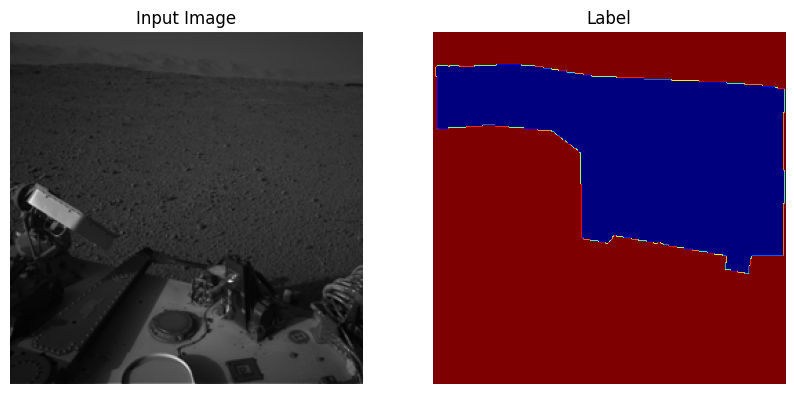

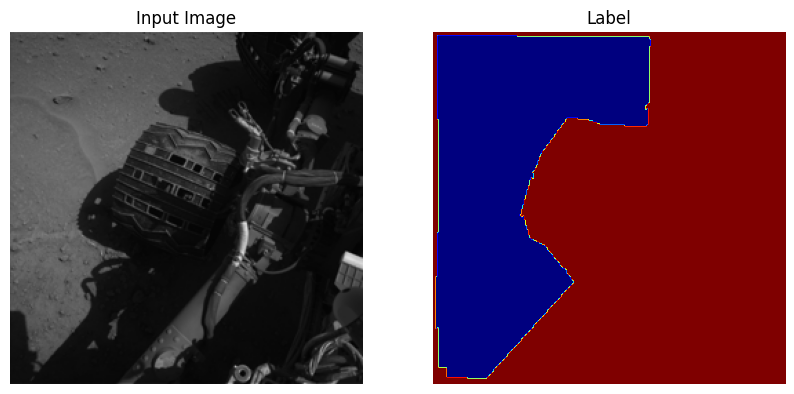

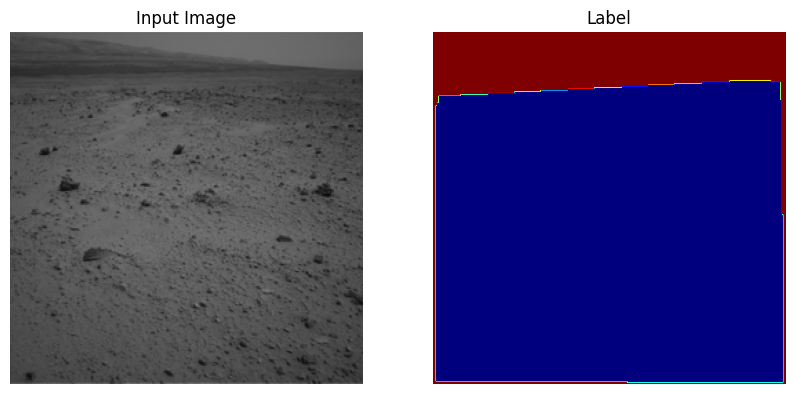

In [8]:
# Get list of image and label files
image_files = sorted(os.listdir(edr))
label_files = sorted(os.listdir(tr_lab))

# Check that files are available
print(f"Number of images: {len(image_files)}")
print(f"Number of labels: {len(label_files)}")

# Function to load an image
def load_image(path, target_size=(IMG_HEIGHT, IMG_WIDTH)):
    img = Image.open(path).convert('RGB')
    img = img.resize(target_size)
    return np.array(img)

# Function to load a label
def load_label(path, target_size=(IMG_HEIGHT, IMG_WIDTH)):
    lbl = Image.open(path)
    lbl = lbl.resize(target_size, Image.NEAREST)  # Use NEAREST for labels
    return np.array(lbl)

# Visualize a few random samples
num_samples = 3
sample_indices = random.sample(range(len(image_files)), num_samples)
# Load and display a few matched images and labels
num_samples = 3
sample_indices = random.sample(range(len(final_image_paths)), num_samples)

for idx in sample_indices:
    image_path = final_image_paths[idx]
    label_path = final_label_paths[idx]
    
    image = load_image(image_path)
    label = load_label(label_path)
    
    plt.figure(figsize=(10, 5))
    
    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title("Input Image")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(label, cmap='jet')
    plt.title("Label")
    plt.axis('off')
    
    plt.show()

In [9]:
# Inspect the unique pixel values in one sample label without encoding
lbl = Image.open(final_label_paths[0])
lbl = lbl.resize((IMG_WIDTH, IMG_HEIGHT), Image.NEAREST)
lbl = np.array(lbl)

print("Unique label values in the sample label:")
print(np.unique(lbl))


Unique label values in the sample label:
[255]


In [10]:
print("Inspecting unique label values in first 5 labels:")

for i in range(5):
    lbl = Image.open(final_label_paths[i])
    lbl = lbl.resize((IMG_WIDTH, IMG_HEIGHT), Image.NEAREST)
    lbl = np.array(lbl)
    unique_vals = np.unique(lbl)
    print(f"Label {i+1}: unique values = {unique_vals}")

Inspecting unique label values in first 5 labels:
Label 1: unique values = [255]
Label 2: unique values = [  0 255]
Label 3: unique values = [  0 255]
Label 4: unique values = [  0 255]
Label 5: unique values = [  0 255]


In [11]:
# Define a mapping for labels
# 0 -> 0 (background), 255 -> 1 (obstacle/bedrock)
LABEL_MAPPING = {0: 0, 255: 1}

def encode_label(lbl, num_classes=NUM_CLASSES):
    # Map original values to class indices
    encoded = np.zeros_like(lbl, dtype=np.uint8)
    for k, v in LABEL_MAPPING.items():
        encoded[lbl == k] = v
    
    # Convert to one-hot encoding
    one_hot = to_categorical(encoded, num_classes=num_classes)
    return one_hot

# Example: test on first label
lbl = load_label(final_label_paths[0])
encoded_label = encode_label(lbl)
print("Shape of one-hot encoded label:", encoded_label.shape)  # Should be (IMG_HEIGHT, IMG_WIDTH, NUM_CLASSES)

Shape of one-hot encoded label: (256, 256, 4)


In [12]:
from tensorflow.keras.utils import Sequence

class MarsDataGenerator(Sequence):
    def __init__(self, image_paths, label_paths, batch_size=8, img_size=(IMG_HEIGHT, IMG_WIDTH), num_classes=NUM_CLASSES, shuffle=True):
        self.image_paths = image_paths
        self.label_paths = label_paths
        self.batch_size = batch_size
        self.img_size = img_size
        self.num_classes = num_classes
        self.shuffle = shuffle
        self.indexes = np.arange(len(self.image_paths))
        self.on_epoch_end()
    
    def __len__(self):
        # Number of batches per epoch
        return int(np.ceil(len(self.image_paths) / self.batch_size))
    
    def __getitem__(self, index):
        # Generate indexes for this batch
        batch_indexes = self.indexes[index*self.batch_size:(index+1)*self.batch_size]
        
        # Get batch paths
        batch_image_paths = [self.image_paths[i] for i in batch_indexes]
        batch_label_paths = [self.label_paths[i] for i in batch_indexes]
        
        # Load and preprocess batch data
        X_batch = np.array([load_image(p)/255.0 for p in batch_image_paths], dtype=np.float32)
        y_batch = np.array([encode_label(load_label(p)) for p in batch_label_paths], dtype=np.float32)
        
        return X_batch, y_batch
    
    def on_epoch_end(self):
        # Shuffle indexes after each epoch
        if self.shuffle:
            np.random.shuffle(self.indexes)

# Usage
BATCH_SIZE = 8

# Split paths for train and validation
train_img_paths, val_img_paths, train_lbl_paths, val_lbl_paths = train_test_split(
    final_image_paths, final_label_paths, test_size=0.2, random_state=SEED
)

# Create generators
train_gen = MarsDataGenerator(train_img_paths, train_lbl_paths, batch_size=BATCH_SIZE)
val_gen = MarsDataGenerator(val_img_paths, val_lbl_paths, batch_size=BATCH_SIZE)

print(f"Training batches: {len(train_gen)}")
print(f"Validation batches: {len(val_gen)}")


Training batches: 1607
Validation batches: 402


## Augmentation

In [13]:
class MarsDataGeneratorAugmented(Sequence):
    def __init__(self, image_paths, label_paths, batch_size=8, img_size=(IMG_HEIGHT, IMG_WIDTH), num_classes=NUM_CLASSES, shuffle=True, augment=True):
        self.image_paths = image_paths
        self.label_paths = label_paths
        self.batch_size = batch_size
        self.img_size = img_size
        self.num_classes = num_classes
        self.shuffle = shuffle
        self.augment = augment
        self.indexes = np.arange(len(self.image_paths))
        self.on_epoch_end()
    
    def __len__(self):
        return int(np.ceil(len(self.image_paths) / self.batch_size))
    
    def __getitem__(self, index):
        batch_indexes = self.indexes[index*self.batch_size:(index+1)*self.batch_size]
        batch_image_paths = [self.image_paths[i] for i in batch_indexes]
        batch_label_paths = [self.label_paths[i] for i in batch_indexes]
        
        X_batch = []
        y_batch = []
        
        for img_path, lbl_path in zip(batch_image_paths, batch_label_paths):
            img = load_image(img_path)/255.0
            lbl = encode_label(load_label(lbl_path))
            
            if self.augment:
                img, lbl = self.augment_pair(img, lbl)
            
            X_batch.append(img)
            y_batch.append(lbl)
        
        return np.array(X_batch, dtype=np.float32), np.array(y_batch, dtype=np.float32)
    
    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)
    
    def augment_pair(self, img, lbl):
        # Random horizontal flip
        if random.random() > 0.5:
            img = np.fliplr(img)
            lbl = np.fliplr(lbl)
        # Random vertical flip
        if random.random() > 0.5:
            img = np.flipud(img)
            lbl = np.flipud(lbl)
        # Random rotation 0, 90, 180, 270 degrees
        k = random.randint(0, 3)
        if k > 0:
            img = np.rot90(img, k)
            lbl = np.rot90(lbl, k)
        return img, lbl

# Usage
train_gen_aug = MarsDataGeneratorAugmented(train_img_paths, train_lbl_paths, batch_size=BATCH_SIZE, augment=True)
val_gen_aug = MarsDataGeneratorAugmented(val_img_paths, val_lbl_paths, batch_size=BATCH_SIZE, augment=False)


In [14]:
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2

def mobile_unet(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3), num_classes=NUM_CLASSES):
    # Encoder: MobileNetV2 as backbone
    base_model = MobileNetV2(input_shape=input_shape, include_top=False, weights='imagenet')
    
    # Encoder layers for skip connections
    skip_names = ["block_1_expand_relu",  # 128x128
                  "block_3_expand_relu",  # 64x64
                  "block_6_expand_relu",  # 32x32
                  "block_13_expand_relu"] # 16x16
    skip_outputs = [base_model.get_layer(name).output for name in skip_names]
    
    encoder_output = base_model.output  # 8x8

    # Decoder
    x = encoder_output
    skip_outputs.reverse()  # start from deepest
    decoder_filters = [512, 256, 128, 64]
    
    for i, skip in enumerate(skip_outputs):
        x = layers.Conv2DTranspose(decoder_filters[i], (3,3), strides=(2,2), padding='same')(x)
        x = layers.Concatenate()([x, skip])
        x = layers.Conv2D(decoder_filters[i], (3,3), padding='same', activation='relu')(x)
        x = layers.Conv2D(decoder_filters[i], (3,3), padding='same', activation='relu')(x)
    
    # Final upsampling to original size
    x = layers.Conv2DTranspose(32, (3,3), strides=(2,2), padding='same')(x)
    x = layers.Conv2D(32, (3,3), padding='same', activation='relu')(x)
    x = layers.Conv2D(num_classes, (1,1), padding='same', activation='softmax')(x)
    
    model = Model(inputs=base_model.input, outputs=x)
    return model

# Create model
model = mobile_unet()
model.summary()

/tmp/ipykernel_101/2607186777.py:6: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=input_shape, include_top=False, weights='imagenet')
I0000 00:00:1759323209.850520     101 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1759323209.851358     101 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 128, 128,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 128, 128,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 128, 128,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 128, 128,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 128, 128,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 128, 128,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 128, 128,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 128, 128,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 129, 129,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 64, 64,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 64, 64,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 64, 64,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 64, 64,    │      2,304 │ block_1_depthwis

 Total params: 19,319,876 (73.70 MB)

 Trainable params: 19,285,764 (73.57 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [22]:
import tensorflow.keras.backend as K

def mean_iou(y_true, y_pred):
    y_true = K.argmax(y_true, axis=-1)
    y_pred = K.argmax(y_pred, axis=-1)
    
    iou = []
    for i in range(NUM_CLASSES):
        intersection = K.sum(K.cast((y_true == i) & (y_pred == i), 'float32'))
        union = K.sum(K.cast((y_true == i) | (y_pred == i), 'float32'))
        iou.append(intersection / (union + K.epsilon()))
    return K.mean(K.stack(iou))

# Define batch-compatible IoU metric
iou_metric = tf.keras.metrics.MeanIoU(num_classes=NUM_CLASSES)

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy', iou_metric]
)

# Callbacks
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "mobile_unet_mars_best.h5",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1
    )
]

# Training parameters
EPOCHS = 50  # adjust as needed
BATCH_SIZE = 4  # same as generator

# Start training
history = model.fit(
    train_gen_aug,
    validation_data=val_gen_aug,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
1607/1607 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 0.8655 - loss: 0.3149 - mean_io_u_4: 0.3842
Epoch 1: val_loss improved from inf to 0.36272, saving model to mobile_unet_mars_best.h5
1607/1607 ━━━━━━━━━━━━━━━━━━━━ 538s 295ms/step - accuracy: 0.8655 - loss: 0.3149 - mean_io_u_4: 0.3842 - val_accuracy: 0.8400 - val_loss: 0.3627 - val_mean_io_u_4: 0.3810 - learning_rate: 1.0000e-04
Epoch 2/50
1607/1607 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.8687 - loss: 0.3044 - mean_io_u_4: 0.3861
Epoch 2: val_loss improved from 0.36272 to 0.30148, saving model to mobile_unet_mars_best.h5
1607/1607 ━━━━━━━━━━━━━━━━━━━━ 443s 276ms/step - accuracy: 0.8687 - loss: 0.3044 - mean_io_u_4: 0.3861 - val_accuracy: 0.8695 - val_loss: 0.3015 - val_mean_io_u_4: 0.3807 - learning_rate: 1.0000e-04
Epoch 3/50
1607/1607 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.8737 - loss: 0.2892 - mean_io_u_4: 0.3848
Epoch 3: val_loss improved from 0.30148 to 0.27365, saving model to mobile_unet_mars

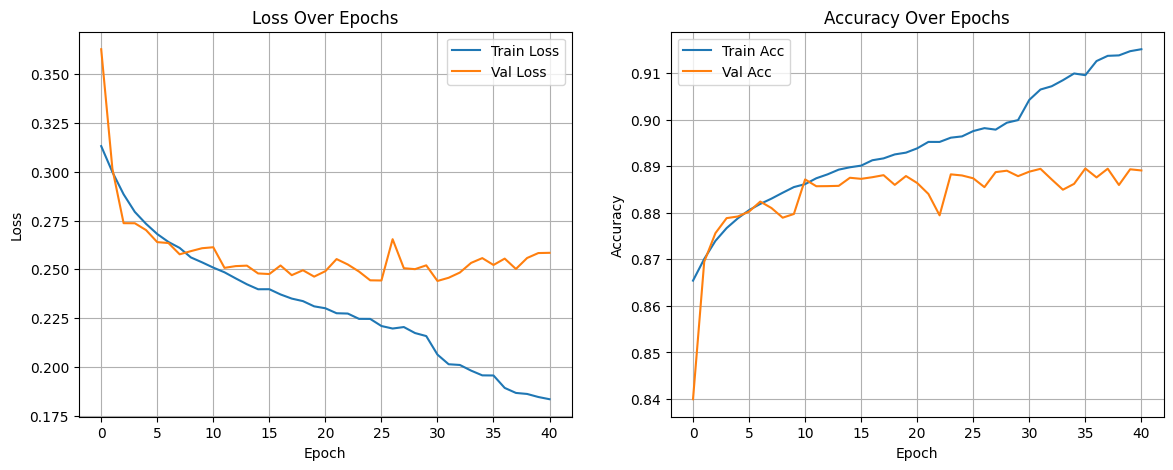

In [23]:
# Plot training history
def plot_training_history(history):
    plt.figure(figsize=(14, 5))

    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title("Loss Over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    # Accuracy (or other metric)
    if 'accuracy' in history.history:
        plt.subplot(1, 2, 2)
        plt.plot(history.history['accuracy'], label='Train Acc')
        plt.plot(history.history['val_accuracy'], label='Val Acc')
        plt.title("Accuracy Over Epochs")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.legend()
        plt.grid(True)

    plt.show()

# Call the function
plot_training_history(history)


402/402 ━━━━━━━━━━━━━━━━━━━━ 77s 190ms/step - accuracy: 0.8911 - loss: 0.2385 - mean_io_u_4: 0.4049

Validation Metrics:
loss: 0.2441
compile_metrics: 0.8888
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


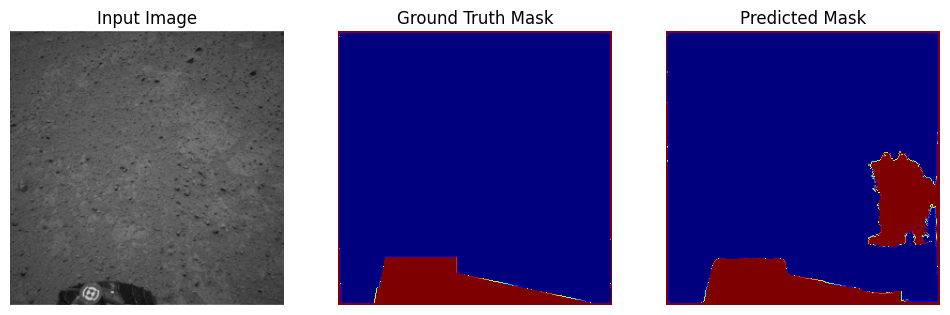

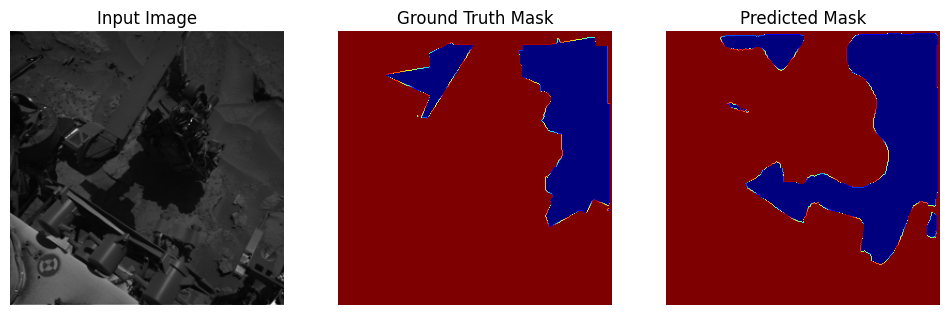

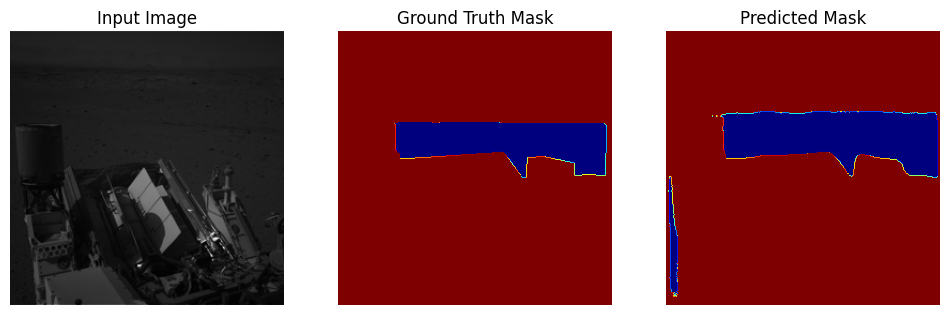

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Evaluate model on validation set
results = model.evaluate(val_gen, verbose=1)

print("\nValidation Metrics:")
for name, value in zip(model.metrics_names, results):
    print(f"{name}: {value:.4f}")


# 2. Visualize predictions on random samples from validation set
import random

# Take one batch from validation generator
images, labels = next(iter(val_gen))

# Run predictions
preds = model.predict(images)
preds = np.argmax(preds, axis=-1)    # Convert softmax to class index
labels = np.argmax(labels, axis=-1)  # Convert one-hot to class index

# Show a few examples
num_samples = 3
for i in range(num_samples):
    plt.figure(figsize=(12, 4))

    # Input image
    plt.subplot(1, 3, 1)
    plt.imshow(images[i])
    plt.title("Input Image")
    plt.axis("off")

    # Ground truth mask
    plt.subplot(1, 3, 2)
    plt.imshow(labels[i], cmap="jet")
    plt.title("Ground Truth Mask")
    plt.axis("off")

    # Predicted mask
    plt.subplot(1, 3, 3)
    plt.imshow(preds[i], cmap="jet")
    plt.title("Predicted Mask")
    plt.axis("off")

    plt.show()

402/402 ━━━━━━━━━━━━━━━━━━━━ 78s 193ms/step - accuracy: 0.8880 - loss: 0.2422 - mean_io_u_4: 0.4058

Validation Metrics:
loss: 0.2441
compile_metrics: 0.8888
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step

Mean IoU (batch): 0.7359
Class 0 IoU: 0.8116
Class 1 IoU: 0.6603
Class 2 IoU: nan
Class 3 IoU: nan


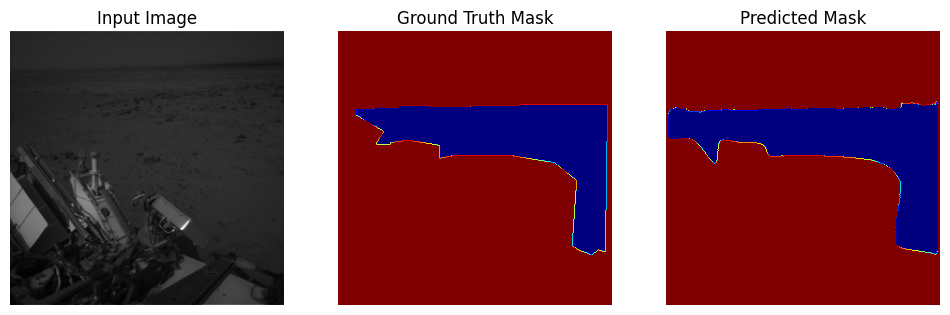

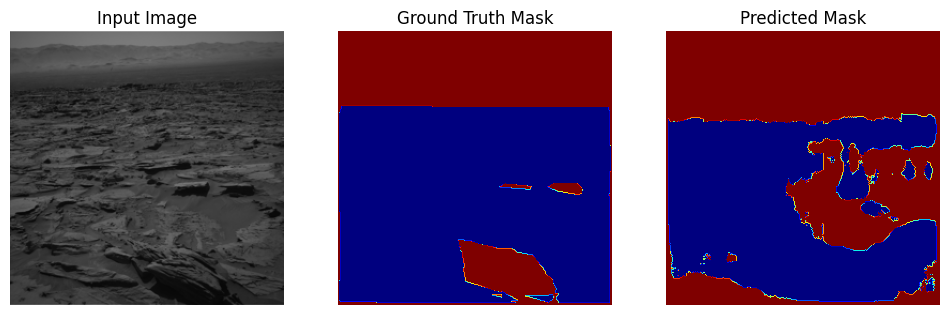

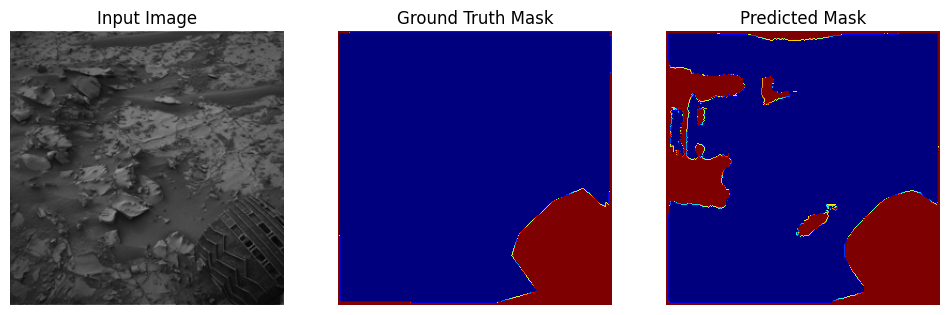

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# 1. Evaluate model on validation set
results = model.evaluate(val_gen, verbose=1)

print("\nValidation Metrics:")
for name, value in zip(model.metrics_names, results):
    print(f"{name}: {value:.4f}")


# 2. Compute Mean IoU manually
def mean_iou(y_true, y_pred, num_classes=NUM_CLASSES):
    # Flatten arrays
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()

    ious = []
    for cls in range(num_classes):
        intersection = np.sum((y_true == cls) & (y_pred == cls))
        union = np.sum((y_true == cls) | (y_pred == cls))
        if union == 0:
            ious.append(np.nan)  # Ignore empty classes
        else:
            ious.append(intersection / union)
    return np.nanmean(ious), ious


# Take one batch from validation set
images, labels = next(iter(val_gen))
preds = model.predict(images)
preds = np.argmax(preds, axis=-1)
labels = np.argmax(labels, axis=-1)

# Calculate IoU for the batch
miou, ious = mean_iou(labels, preds, num_classes=NUM_CLASSES)
print(f"\nMean IoU (batch): {miou:.4f}")
for cls_id, iou in enumerate(ious):
    print(f"Class {cls_id} IoU: {iou:.4f}")


# 3. Visualize predictions
num_samples = 3
for i in range(num_samples):
    plt.figure(figsize=(12, 4))

    # Input image
    plt.subplot(1, 3, 1)
    plt.imshow(images[i])
    plt.title("Input Image")
    plt.axis("off")

    # Ground truth mask
    plt.subplot(1, 3, 2)
    plt.imshow(labels[i], cmap="jet")
    plt.title("Ground Truth Mask")
    plt.axis("off")

    # Predicted mask
    plt.subplot(1, 3, 3)
    plt.imshow(preds[i], cmap="jet")
    plt.title("Predicted Mask")
    plt.axis("off")

    plt.show()
